# M9.2 · Anomaly-based Risk Score (Isolation Forest)

**Goal.** Produce a continuous **risk score in [0, 1]** per (tenant, device, year_month) without ground-truth labels.

**Why Isolation Forest, not supervised classification?**
- The EDA (2026-04-30) showed harsh-event activity and overspeed activity are **inversely correlated** globally (3.5× lower overspeed in harsh-active devices). Using either as a proxy label produces a model that argues against itself.
- Isolation Forest needs no labels. It scores how "unusual" a device-month is relative to its tenant cohort — a defensible operational definition of "risky behavior."

**Scope decisions enforced (matching notebook 01):**
- **F3** — `year_month >= '2025-01'`.
- **F4** — Per-tenant model. Score is meaningful only **within** a tenant's cohort.
- **F5** — Per-device, not per-driver.
- **F6** — No proxy labels.

**Output:** `data/ml/device_risk_scores.parquet` and a `risk_score` column joinable on (tenant_id, device_id, year_month).

In [1]:
from __future__ import annotations
import sys, pathlib
PROJECT_ROOT = pathlib.Path().resolve().parents[1] if pathlib.Path().resolve().name != 'accent-fleet-analytics' else pathlib.Path().resolve()
for c in (PROJECT_ROOT, PROJECT_ROOT.parent):
    src = c / 'src'
    if src.exists() and str(src) not in sys.path:
        sys.path.insert(0, str(src)); break

import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
from accent_fleet.db import get_engine
from sqlalchemy import text

## 2. Inputs (same window/filter as notebook 01)

In [2]:
FEATURES = [
    'overspeed_per_100km', 'avg_speed_over_limit', 'high_speed_trip_ratio',
    'speed_alert_per_100km',
    'harsh_brake_per_100km', 'harsh_accel_per_100km', 'harsh_corner_per_100km',
    'monthly_idle_ratio', 'high_rpm_minutes_per_day',
    'night_trip_ratio', 'rush_hour_trip_ratio',
    'stddev_trip_distance', 'short_trip_ratio',
]
ID_COLS = ['tenant_id', 'device_id', 'year_month']

with get_engine().connect() as conn:
    df = pd.read_sql(text('''
        SELECT * FROM marts.v_ml_features_full
        WHERE year_month >= '2025-01'
          AND total_distance_km >= 100
          AND total_ignition_on_minutes > 0
    '''), conn)
print('rows:', len(df))

rows: 1723


## 3. Per-tenant Isolation Forest (F4)

`contamination='auto'` lets the model pick the threshold; we keep the raw `decision_function` and rescale to [0, 1] across the tenant cohort. **Higher = more anomalous = higher risk.**

In [3]:
def fit_one_tenant(sub: pd.DataFrame):
    X = sub[FEATURES].fillna(0).to_numpy()
    if len(X) < 50:
        return None
    Xs = StandardScaler().fit_transform(X)
    iso = IsolationForest(n_estimators=200, contamination='auto',
                          random_state=42, n_jobs=-1).fit(Xs)
    raw = -iso.decision_function(Xs)  # higher = more anomalous
    score = (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)
    out = sub[ID_COLS].copy()
    out['risk_score'] = score
    out['risk_band'] = pd.cut(score, bins=[-0.01, 0.4, 0.7, 1.01],
                               labels=['low', 'medium', 'high'])
    return out

scores = []
for tenant_id, sub in df.groupby('tenant_id'):
    r = fit_one_tenant(sub)
    if r is None:
        print(f'tenant {tenant_id}: only {len(sub)} rows — skipped'); continue
    scores.append(r)
    print(f'tenant {tenant_id}: n={len(sub):>4d}  high={(r.risk_band=="high").sum():>3d}  med={(r.risk_band=="medium").sum():>3d}  low={(r.risk_band=="low").sum():>4d}')
scores = pd.concat(scores, ignore_index=True)

tenant 235: n= 613  high= 19  med= 93  low= 501
tenant 238: n= 339  high=  8  med= 50  low= 281
tenant 264: n= 354  high= 20  med= 66  low= 268
tenant 1787: n= 417  high=  4  med= 77  low= 336


## 4. Sanity check: do high-risk rows look risky?

Within each tenant, `high` band rows should show elevated overspeed + harsh + idle vs `low` band rows. This is **internal consistency**, not external validation — we have no ground truth.

In [4]:
joined = scores.merge(df[ID_COLS + FEATURES], on=ID_COLS, how='left')
for tenant_id, sub in joined.groupby('tenant_id'):
    profile = sub.groupby('risk_band', observed=True)[FEATURES].mean().round(2)
    print(f'\n=== tenant {tenant_id} ===')
    display(profile)


=== tenant 235 ===


,overspeed_per_100km,avg_speed_over_limit,high_speed_trip_ratio,speed_alert_per_100km,harsh_brake_per_100km,harsh_accel_per_100km,harsh_corner_per_100km,monthly_idle_ratio,high_rpm_minutes_per_day,night_trip_ratio,rush_hour_trip_ratio,stddev_trip_distance,short_trip_ratio
risk_band,,,,,,,,,,,,,
low,0.09,0.38,0.01,0.0,3.22,3.31,4.57,0.11,1.53,0.11,0.23,21.13,0.38
medium,1.89,3.06,0.02,0.0,10.27,20.80,31.01,0.15,7.91,0.16,0.22,30.05,0.36
high,3.03,4.52,0.02,0.0,44.58,76.17,144.37,0.12,15.05,0.06,0.25,18.78,0.38



=== tenant 238 ===


,overspeed_per_100km,avg_speed_over_limit,high_speed_trip_ratio,speed_alert_per_100km,harsh_brake_per_100km,harsh_accel_per_100km,harsh_corner_per_100km,monthly_idle_ratio,high_rpm_minutes_per_day,night_trip_ratio,rush_hour_trip_ratio,stddev_trip_distance,short_trip_ratio
risk_band,,,,,,,,,,,,,
low,0.02,0.39,0.02,0.00,2.91,4.39,5.99,0.08,2.54,0.10,0.22,25.15,0.34
medium,0.32,3.01,0.03,1.94,6.78,14.74,17.55,0.22,7.70,0.10,0.23,28.64,0.36
high,0.03,0.38,0.00,2.31,67.48,177.84,344.73,0.16,0.00,0.03,0.22,14.62,0.42



=== tenant 264 ===


,overspeed_per_100km,avg_speed_over_limit,high_speed_trip_ratio,speed_alert_per_100km,harsh_brake_per_100km,harsh_accel_per_100km,harsh_corner_per_100km,monthly_idle_ratio,high_rpm_minutes_per_day,night_trip_ratio,rush_hour_trip_ratio,stddev_trip_distance,short_trip_ratio
risk_band,,,,,,,,,,,,,
low,3.66,4.15,0.02,4.44,0.16,0.11,1.04,0.04,0.0,0.13,0.23,39.46,0.26
medium,5.55,6.17,0.05,6.00,1.35,1.80,6.07,0.20,0.0,0.13,0.23,34.48,0.33
high,4.83,7.12,0.03,3.95,4.81,7.65,7.27,0.42,0.0,0.15,0.24,26.59,0.53



=== tenant 1787 ===


,overspeed_per_100km,avg_speed_over_limit,high_speed_trip_ratio,speed_alert_per_100km,harsh_brake_per_100km,harsh_accel_per_100km,harsh_corner_per_100km,monthly_idle_ratio,high_rpm_minutes_per_day,night_trip_ratio,rush_hour_trip_ratio,stddev_trip_distance,short_trip_ratio
risk_band,,,,,,,,,,,,,
low,0.02,0.52,0.03,0.16,4.32,6.80,14.87,0.10,0.0,0.10,0.23,19.45,0.36
medium,0.15,2.45,0.04,0.40,37.30,42.79,60.62,0.16,0.0,0.12,0.22,22.12,0.42
high,0.48,11.46,0.09,1.47,14.70,31.10,55.30,0.20,0.0,0.15,0.28,32.23,0.44


## 5. Score distribution per tenant

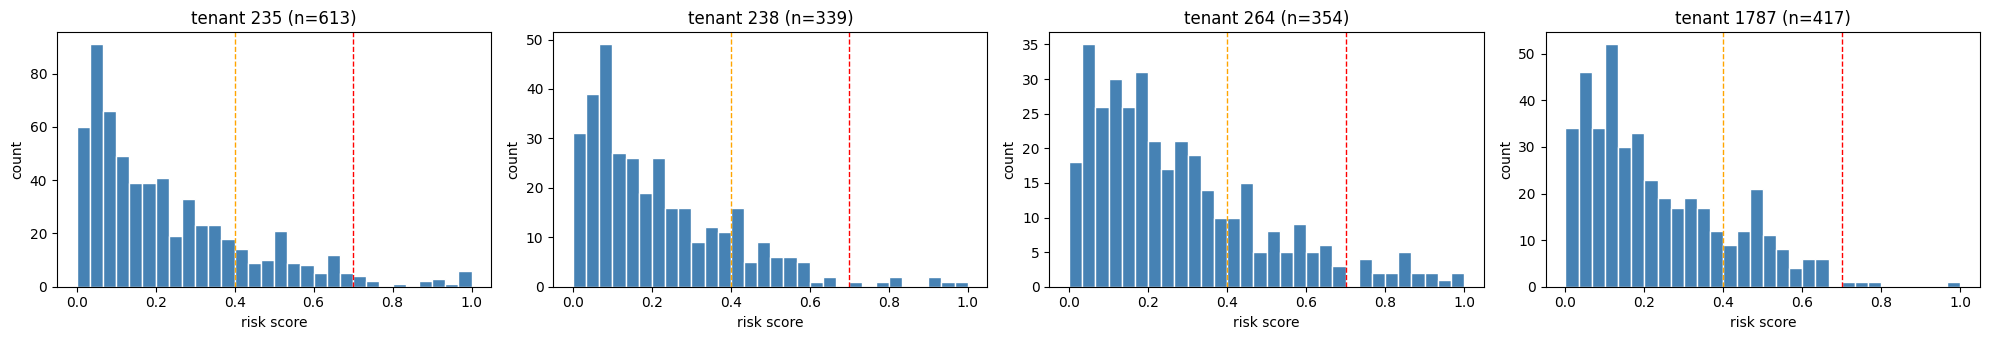

In [5]:
tenants = sorted(scores.tenant_id.unique())
fig, axes = plt.subplots(1, len(tenants), figsize=(5*len(tenants), 3.5), squeeze=False)
for ax, t in zip(axes[0], tenants):
    s = scores.loc[scores.tenant_id == t, 'risk_score']
    ax.hist(s, bins=30, color='steelblue', edgecolor='white')
    ax.set_title(f'tenant {t} (n={len(s)})')
    ax.set_xlabel('risk score'); ax.set_ylabel('count')
    ax.axvline(0.4, color='orange', ls='--', lw=1)
    ax.axvline(0.7, color='red', ls='--', lw=1)
plt.tight_layout(); plt.show()

## 6. Persist scores

In [6]:
out_dir = pathlib.Path('../../data/ml'); out_dir.mkdir(parents=True, exist_ok=True)
scores.to_parquet(out_dir / 'device_risk_scores.parquet', index=False)
print('wrote', out_dir / 'device_risk_scores.parquet', 'rows:', len(scores))

wrote ..\..\data\ml\device_risk_scores.parquet rows: 1723


## 7. Exit gate

We pass if every tenant got a score (no skipped tenants for low n) **and** the high-risk band shows higher mean overspeed_per_100km than the low band within at least one tenant. This is the minimum sanity bar replacing the abandoned >0.7 correlation goal.

In [7]:
ok = []
for tenant_id, sub in joined.groupby('tenant_id'):
    by_band = sub.groupby('risk_band', observed=True)['overspeed_per_100km'].mean()
    if 'high' in by_band.index and 'low' in by_band.index:
        ok.append((tenant_id, by_band.get('high', 0) > by_band.get('low', 0)))
print('tenants where high > low overspeed:', [t for t, b in ok if b])
assert any(b for _, b in ok), 'No tenant showed the expected high>low overspeed pattern.'

tenants where high > low overspeed: [235, 238, 264, 1787]
